# Sign-invariant walking-frame CNN

The v1 walking-frame features had a 180-degree pocket-rotation sign
ambiguity in `a_f` and `a_s` (rotating the phone by pi about gravity
flips `f_hat`, which flips the projections). v2 replaces those signed
channels with their magnitudes, `a_f_mag = |a_f|` and `a_s_mag = |a_s|`,
giving a feature set that is *fully* invariant to any rotation about
the gravity axis. `gyro_v` stays signed because its sign depends only
on the gravity convention, which is now fixed (Android->iOS conversion
audited against the Sensor Logger docs).

> Mizell, D. (2003). Using gravity to estimate accelerometer orientation. *ISWC 2003*, 252-253.
> Henpraserttae, A. et al. (2011). Accurate activity recognition using a mobile phone regardless of device orientation and location. *BSN 2011*, 41-46.

In [1]:
import os, sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf, keras
from keras import layers, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupKFold

warnings.filterwarnings('ignore')
SEED = 42; np.random.seed(SEED); tf.random.set_seed(SEED)

_ROOT = Path('..').resolve(); sys.path.insert(0, str(_ROOT))
from utils.orientation_invariant_features import (
    compute_features, compute_walking_frame_features, compute_walking_frame_features_v2,
    ORIENTATION_INVARIANT_COLS, WALKING_FRAME_COLS, WALKING_FRAME_V2_COLS,
)
print('v2 columns:', WALKING_FRAME_V2_COLS)


v2 columns: ['acc_mag', 'gyro_mag', 'a_v', 'a_h', 'jerk_v', 'a_f_mag', 'a_s_mag', 'gyro_v']


In [2]:
ACT_LABELS = ['dws','ups','wlk','jog','std','sit']
TRIAL_CODES = {
    'dws': [1,2,11], 'ups': [3,4,12], 'wlk': [7,8,15],
    'jog': [9,16],   'std': [6,14],   'sit': [5,13],
}


def get_ds_infos(): return pd.read_csv('../../data/data_subjects_info.csv')
def set_data_types(types):
    return [[t+'.x',t+'.y',t+'.z'] if t!='attitude' else ['attitude.roll','attitude.pitch','attitude.yaw'] for t in types]


def create_time_series(dt_list, act_labels, trial_codes):
    n_cols = len(dt_list)*3
    dataset = np.zeros((0, n_cols+7))
    ds_list = get_ds_infos()
    for sub_id in ds_list['code']:
        for act_id, act in enumerate(act_labels):
            for trial in trial_codes[act]:
                f = f'../../data/A_DeviceMotion_data/{act}_{trial}/sub_{int(sub_id)}.csv'
                raw = pd.read_csv(f).drop(['Unnamed: 0'], axis=1)
                vals = np.zeros((len(raw), n_cols))
                for x, axes in enumerate(dt_list):
                    vals[:, x*3:(x+1)*3] = raw[axes].values
                lbls = np.array([[act_id, sub_id-1,
                                  ds_list['weight'][sub_id-1],
                                  ds_list['height'][sub_id-1],
                                  ds_list['age'][sub_id-1],
                                  ds_list['gender'][sub_id-1], trial]] * len(raw))
                dataset = np.append(dataset, np.concatenate((vals, lbls), axis=1), axis=0)
    cols = [c for axes in dt_list for c in axes] + ['act','id','weight','height','age','gender','trial']
    return pd.DataFrame(data=dataset, columns=cols)


def sliding_windows(data, feature_cols, w=128, s=64):
    X, y, g = [], [], []
    for (sid, act, _), b in data.groupby(['id','act','trial'], sort=False):
        v = b[feature_cols].to_numpy()
        for st in range(0, len(v)-w+1, s):
            X.append(v[st:st+w]); y.append(act); g.append(sid)
    return np.array(X), np.array(y), np.array(g)


dt_list = set_data_types(['attitude','gravity','rotationRate','userAcceleration'])
dataset = create_time_series(dt_list, ACT_LABELS, TRIAL_CODES)
for col in ('act','id','trial'): dataset[col] = dataset[col].astype(int)

features_df = compute_walking_frame_features_v2(dataset, fs_hz=50.0, smooth_seconds=5.0)
print('features_df shape:', features_df.shape)
features_df[WALKING_FRAME_V2_COLS].describe().round(3)


features_df shape: (1412865, 15)


,acc_mag,gyro_mag,a_v,a_h,jerk_v,a_f_mag,a_s_mag,gyro_v
count,1412865.000,1412865.000,1412865.000,1412865.000,1412865.000,1412865.000,1412865.000,1412865.000
mean,0.425,1.244,-0.004,0.270,0.000,0.189,0.152,-0.007
std,0.592,1.510,0.557,0.384,23.039,0.308,0.258,1.163
min,0.000,0.000,-5.479,0.000,-548.865,0.000,0.000,-14.597
25%,0.027,0.028,-0.095,0.025,-1.028,0.018,0.004,-0.180
50%,0.197,0.694,0.003,0.115,0.000,0.064,0.036,-0.000
75%,0.618,2.071,0.020,0.381,1.027,0.238,0.204,0.202
max,10.113,21.968,8.831,9.514,546.752,9.498,7.881,16.517


In [3]:
train_ids = list(range(0, 15)); val_ids = list(range(15, 19)); test_ids = list(range(19, 24))
X_train, y_train, g_train = sliding_windows(features_df[features_df['id'].isin(train_ids)], WALKING_FRAME_V2_COLS)
X_val,   y_val,   g_val   = sliding_windows(features_df[features_df['id'].isin(val_ids)],   WALKING_FRAME_V2_COLS)
X_test,  y_test,  g_test  = sliding_windows(features_df[features_df['id'].isin(test_ids)],  WALKING_FRAME_V2_COLS)
y_train, y_val, y_test = y_train.astype(int), y_val.astype(int), y_test.astype(int)
N_CHAN = len(WALKING_FRAME_V2_COLS)


def normalize_dyn(X, eps=1e-8):
    out = X.copy().astype(np.float32)
    return (out - out.mean(axis=1, keepdims=True)) / (out.std(axis=1, keepdims=True) + eps)


X_train_n = normalize_dyn(X_train); X_val_n = normalize_dyn(X_val); X_test_n = normalize_dyn(X_test)
print(f'shapes: train {X_train_n.shape}, val {X_val_n.shape}, test {X_test_n.shape}')


shapes: train (13282, 128, 8), val (3905, 128, 8), test (4352, 128, 8)


In [4]:
def build_cnn_baseline(input_shape=(128, N_CHAN), n_classes=6):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 5, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling1D(2)(x)
    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x); x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation='relu')(x); x = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    return keras.Model(inp, out, name='cnn_baseline_wf_v2')


tf.keras.backend.clear_session(); tf.random.set_seed(SEED); np.random.seed(SEED)
cnn = build_cnn_baseline()
cw = compute_class_weight('balanced', classes=np.arange(6), y=y_train)
class_weight = {int(i): float(w) for i, w in enumerate(cw)}

cnn.compile(optimizer=keras.optimizers.Adam(1e-3),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cb = [callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
      callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=1e-6, verbose=1)]
history = cnn.fit(X_train_n, y_train, validation_data=(X_val_n, y_val),
                  epochs=50, batch_size=32, class_weight=class_weight, callbacks=cb, verbose=2)


Epoch 1/50


416/416 - 7s - 17ms/step - accuracy: 0.9014 - loss: 0.2874 - val_accuracy: 0.7667 - val_loss: 0.6316 - learning_rate: 0.0010


Epoch 2/50


416/416 - 6s - 13ms/step - accuracy: 0.9563 - loss: 0.1198 - val_accuracy: 0.7134 - val_loss: 1.0061 - learning_rate: 0.0010


Epoch 3/50


...

Epoch 10/50


416/416 - 6s - 15ms/step - accuracy: 0.9998 - loss: 0.0015 - val_accuracy: 0.8430 - val_loss: 0.8105 - learning_rate: 5.0000e-04


Epoch 11/50



Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.


416/416 - 6s - 14ms/step - accuracy: 0.9998 - loss: 9.7784e-04 - val_accuracy: 0.8289 - val_loss: 0.9702 - learning_rate: 5.0000e-04


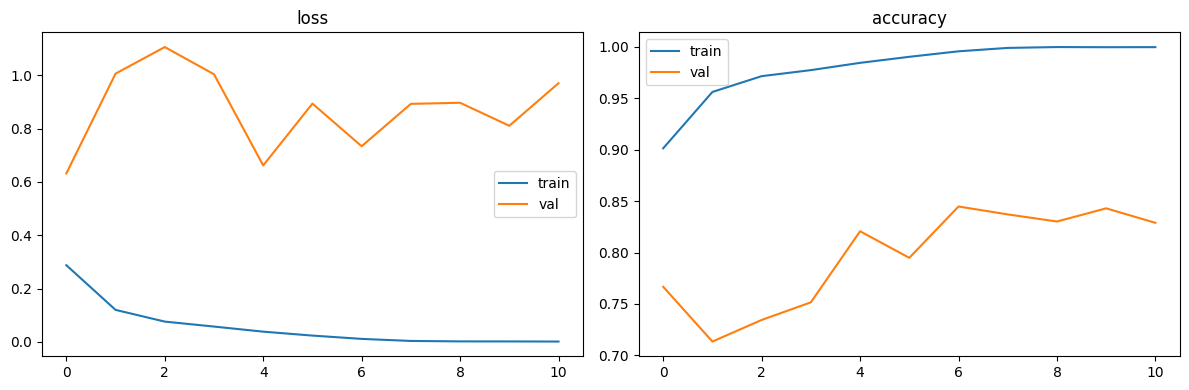

              precision    recall  f1-score   support

         dws     0.9234    0.9507    0.9369       406
         ups     0.8737    0.9803    0.9239       508
         wlk     0.9865    0.8603    0.9190      1102
         jog     0.9635    0.9791    0.9712       431
         std     0.8535    0.9459    0.8973       979
         sit     0.9352    0.8888    0.9114       926

    accuracy                         0.9198      4352
   macro avg     0.9226    0.9342    0.9266      4352
weighted avg     0.9243    0.9198    0.9199      4352

MotionSense macro-F1: 0.9266  acc: 0.9198


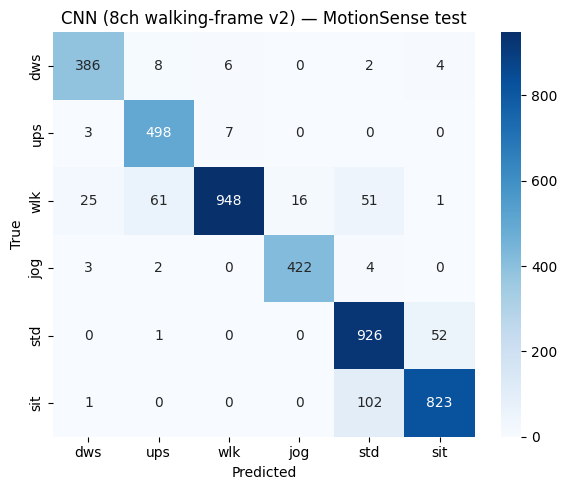

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='train'); axes[0].plot(history.history['val_loss'], label='val')
axes[0].set_title('loss'); axes[0].legend()
axes[1].plot(history.history['accuracy'], label='train'); axes[1].plot(history.history['val_accuracy'], label='val')
axes[1].set_title('accuracy'); axes[1].legend()
plt.tight_layout(); plt.show()

yp = cnn.predict(X_test_n, verbose=0).argmax(axis=1)
macro_f1 = f1_score(y_test, yp, average='macro')
acc = float((yp == y_test).mean())
print(classification_report(y_test, yp, target_names=ACT_LABELS, digits=4))
print(f'MotionSense macro-F1: {macro_f1:.4f}  acc: {acc:.4f}')

cm = confusion_matrix(y_test, yp)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACT_LABELS, yticklabels=ACT_LABELS, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('CNN (8ch walking-frame v2) — MotionSense test')
plt.tight_layout(); plt.show()


## 5-fold subject-wise CV

In [6]:
X_full, y_full, g_full = sliding_windows(features_df, WALKING_FRAME_V2_COLS)
y_full = y_full.astype(int)
X_full_n = normalize_dyn(X_full)

gkf = GroupKFold(n_splits=5); fold_f1s = []
for fold, (tr, te) in enumerate(gkf.split(X_full_n, y_full, groups=g_full)):
    tf.keras.backend.clear_session(); tf.random.set_seed(SEED); np.random.seed(SEED)
    m = build_cnn_baseline()
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    cw_f = compute_class_weight('balanced', classes=np.arange(6), y=y_full[tr])
    m.fit(X_full_n[tr], y_full[tr], epochs=25, batch_size=32,
          class_weight={int(i): float(w) for i, w in enumerate(cw_f)}, verbose=0)
    yfp = m.predict(X_full_n[te], verbose=0).argmax(axis=1)
    f1 = f1_score(y_full[te], yfp, average='macro'); fold_f1s.append(f1)
    print(f'fold {fold+1}  subj={sorted(np.unique(g_full[te]).astype(int).tolist())}  macro-F1={f1:.4f}')
fold_f1s = np.array(fold_f1s)
print(f'\nmacro-F1: {fold_f1s.mean():.4f} ± {fold_f1s.std():.4f}')


fold 1  subj=[9, 13, 18, 22]  macro-F1=0.8371


fold 2  subj=[7, 8, 19, 20, 23]  macro-F1=0.8988


fold 3  subj=[5, 6, 11, 15, 21]  macro-F1=0.9510


fold 4  subj=[0, 4, 14, 16, 17]  macro-F1=0.9032


fold 5  subj=[1, 2, 3, 10, 12]  macro-F1=0.9440

macro-F1: 0.9068 ± 0.0407


## Save artefacts

In [7]:
os.makedirs('../../models', exist_ok=True); os.makedirs('../results', exist_ok=True)
cnn.save('../../models/cnn_wf_v2_baseline.keras')
with open('../../models/cnn_wf_v2_baseline.preproc.json', 'w') as f:
    json.dump({
        'channel_order': WALKING_FRAME_V2_COLS,
        'window_size': 128, 'step': 64, 'fs_hz': 50.0, 'smooth_seconds': 5.0,
        'feature_module': 'utils.orientation_invariant_features.compute_walking_frame_features_v2',
        'all_dynamic_zscore': True,
    }, f, indent=2)
print('saved cnn_wf_v2_baseline.{keras,preproc.json}')


saved cnn_wf_v2_baseline.{keras,preproc.json}


## In-the-wild robustness — apples to apples comparison

Inference of all four candidate models on the labelled Android sessions
under `data/in_the_wild/labels.csv`. Uses the corrected Android->iOS
conversion (single z-flip, no roll-flip, yaw-flip added).

In [8]:
G = 9.80665
labels_df = pd.read_csv('../../data/in_the_wild/labels.csv').set_index('session_dir')


def load_session(session_dir):
    base = Path('../../data') / session_dir
    df_ori  = pd.read_csv(base/'Orientation.csv').sort_values('time')
    df_grav = pd.read_csv(base/'Gravity.csv').sort_values('time')
    df_gyr  = pd.read_csv(base/'Gyroscope.csv').sort_values('time')
    df_tot  = pd.read_csv(base/'TotalAcceleration.csv').sort_values('time')
    df = pd.merge_asof(df_ori[['time','roll','pitch','yaw']],
                       df_grav[['time','x','y','z']], on='time', suffixes=('','_grav'))
    df = pd.merge_asof(df, df_gyr[['time','x','y','z']], on='time', suffixes=('','_gyro'))
    df = pd.merge_asof(df, df_tot[['time','x','y','z']], on='time', suffixes=('','_tot_acc'))
    df.columns = ['time','attitude.roll','attitude.pitch','attitude.yaw',
                  'raw_gravity.x','raw_gravity.y','raw_gravity.z',
                  'rotationRate.x','rotationRate.y','rotationRate.z',
                  'raw_total_acc.x','raw_total_acc.y','raw_total_acc.z']
    df['time_dt'] = pd.to_datetime(df['time'])
    df = df.set_index('time_dt').resample('20ms').mean(numeric_only=True).interpolate(method='linear').reset_index(drop=True)

    df['raw_linear_acc.x'] = df['raw_total_acc.x'] - df['raw_gravity.x']
    df['raw_linear_acc.y'] = df['raw_total_acc.y'] - df['raw_gravity.y']
    df['raw_linear_acc.z'] = df['raw_total_acc.z'] - df['raw_gravity.z']
    df['gravity.x'] = -df['raw_gravity.x'] / G
    df['gravity.y'] = -df['raw_gravity.y'] / G
    df['gravity.z'] = -df['raw_gravity.z'] / G
    df['userAcceleration.x'] = -df['raw_linear_acc.x'] / G
    df['userAcceleration.y'] = -df['raw_linear_acc.y'] / G
    df['userAcceleration.z'] = -df['raw_linear_acc.z'] / G
    df['attitude.pitch'] = -df['attitude.pitch']
    df['attitude.yaw']   = -df['attitude.yaw']
    df['attitude.yaw']   = df['attitude.yaw'] - df['attitude.yaw'].iloc[0]

    cols = ['attitude.roll','attitude.pitch','attitude.yaw',
            'gravity.x','gravity.y','gravity.z',
            'rotationRate.x','rotationRate.y','rotationRate.z',
            'userAcceleration.x','userAcceleration.y','userAcceleration.z']
    return df[cols].iloc[150:-150].reset_index(drop=True)


def window_into_batches(arr, w=128, s=64):
    if len(arr) < w: return np.empty((0, w, arr.shape[1]))
    return np.stack([arr[st:st+w] for st in range(0, len(arr)-w+1, s)], axis=0)


In [9]:
interp = tf.lite.Interpreter(model_path='../../models/cnn_best.tflite')
interp.allocate_tensors()
inp_idx, out_idx = interp.get_input_details()[0]['index'], interp.get_output_details()[0]['index']


def predict_12ch(X):
    Xn = X.copy().astype(np.float32)
    dyn = Xn[:,:,6:12]
    Xn[:,:,6:12] = (dyn - dyn.mean(axis=1, keepdims=True)) / (dyn.std(axis=1, keepdims=True) + 1e-8)
    out = np.zeros((len(Xn), 6), dtype=np.float32)
    for i, w in enumerate(Xn):
        interp.set_tensor(inp_idx, w[None]); interp.invoke()
        out[i] = interp.get_tensor(out_idx)[0]
    return out


cnn_oinv = keras.models.load_model('../../models/cnn_oinv_baseline.keras')
with open('../../models/cnn_oinv_baseline.preproc.json') as f:
    oinv_meta = json.load(f)
DYN_OINV = oinv_meta['dynamic_channel_indices']


def predict_oinv(X):
    Xn = X.copy().astype(np.float32)
    dyn = Xn[:,:,DYN_OINV]
    Xn[:,:,DYN_OINV] = (dyn - dyn.mean(axis=1, keepdims=True)) / (dyn.std(axis=1, keepdims=True) + 1e-8)
    return cnn_oinv.predict(Xn, verbose=0)


cnn_wf_v1 = keras.models.load_model('../../models/cnn_wf_baseline.keras')
cnn_wf_v2 = cnn  # just trained in this notebook


def predict_dyn_all(model, X):
    Xn = X.copy().astype(np.float32)
    Xn = (Xn - Xn.mean(axis=1, keepdims=True)) / (Xn.std(axis=1, keepdims=True) + 1e-8)
    return model.predict(Xn, verbose=0)


In [10]:
rows = []
for session, row in labels_df.iterrows():
    gt = int(row['activity_id'])
    df_raw = load_session(session)
    raw_np = df_raw.to_numpy()
    w12 = window_into_batches(raw_np)
    if len(w12) == 0: continue

    feats_oinv = compute_features(df_raw, fs_hz=50.0, group_cols=None, keep_meta=False)
    wo = window_into_batches(feats_oinv[ORIENTATION_INVARIANT_COLS].to_numpy())
    feats_wf1 = compute_walking_frame_features(df_raw, fs_hz=50.0, smooth_seconds=5.0,
                                                group_cols=None, keep_meta=False)
    ww1 = window_into_batches(feats_wf1[WALKING_FRAME_COLS].to_numpy())
    feats_wf2 = compute_walking_frame_features_v2(df_raw, fs_hz=50.0, smooth_seconds=5.0,
                                                   group_cols=None, keep_meta=False)
    ww2 = window_into_batches(feats_wf2[WALKING_FRAME_V2_COLS].to_numpy())

    p12 = predict_12ch(w12).argmax(axis=1)
    po  = predict_oinv(wo).argmax(axis=1)
    pw1 = predict_dyn_all(cnn_wf_v1, ww1).argmax(axis=1)
    pw2 = predict_dyn_all(cnn_wf_v2, ww2).argmax(axis=1)

    c12 = float((p12 == gt).mean()); co = float((po == gt).mean())
    cw1 = float((pw1 == gt).mean()); cw2 = float((pw2 == gt).mean())
    rows.append({
        'session': session, 'orientation': row['pocket_orientation'],
        'true': ACT_LABELS[gt],
        '12ch': c12, '6ch_oinv': co, '8ch_wf_v1': cw1, '8ch_wf_v2': cw2,
        'n_windows': len(p12),
    })
    print(f'{session:<22s} gt={ACT_LABELS[gt]:<4s}  12ch={c12*100:5.1f}%   '
          f'6ch_oinv={co*100:5.1f}%   wf_v1={cw1*100:5.1f}%   wf_v2={cw2*100:5.1f}%')

res = pd.DataFrame(rows).set_index('session')


dws                    gt=dws   12ch=  0.0%   6ch_oinv=  0.0%   wf_v1=100.0%   wf_v2= 75.0%


ups                    gt=ups   12ch=100.0%   6ch_oinv=100.0%   wf_v1=100.0%   wf_v2=100.0%


hod                    gt=wlk   12ch= 22.2%   6ch_oinv=  0.0%   wf_v1=  0.0%   wf_v2=  0.0%


hod2                   gt=wlk   12ch=100.0%   6ch_oinv=100.0%   wf_v1= 66.7%   wf_v2=100.0%


hodanje                gt=wlk   12ch= 38.5%   6ch_oinv= 23.1%   wf_v1= 46.2%   wf_v2= 46.2%


...

jog                    gt=jog   12ch=  0.0%   6ch_oinv=  0.0%   wf_v1=100.0%   wf_v2=100.0%


ED                     gt=wlk   12ch= 57.6%   6ch_oinv= 93.9%   wf_v1= 78.8%   wf_v2= 93.9%


EG                     gt=wlk   12ch=100.0%   6ch_oinv=  0.0%   wf_v1= 32.6%   wf_v2= 86.0%


KD                     gt=wlk   12ch=  0.0%   6ch_oinv=  0.0%   wf_v1= 47.2%   wf_v2= 91.7%


KG                     gt=wlk   12ch= 76.9%   6ch_oinv= 82.1%   wf_v1= 33.3%   wf_v2= 92.3%


In [11]:
def agg(col):
    weights = res['n_windows'].to_numpy(); fracs = res[col].to_numpy()
    return float(np.average(fracs, weights=weights)), float((fracs > 0.5).mean())


vals = {c: agg(c) for c in ['12ch', '6ch_oinv', '8ch_wf_v1', '8ch_wf_v2']}
summary = pd.DataFrame({
    'window_acc':  [vals[c][0] for c in ['12ch', '6ch_oinv', '8ch_wf_v1', '8ch_wf_v2']],
    'session_acc': [vals[c][1] for c in ['12ch', '6ch_oinv', '8ch_wf_v1', '8ch_wf_v2']],
}, index=['CNN-1D baseline (12ch raw)',
          'CNN-1D baseline (6ch orientation-invariant)',
          'CNN-1D baseline (8ch walking-frame v1)',
          'CNN-1D baseline (8ch walking-frame v2, sign-invariant)'])
print(summary.round(4).to_string())

res.to_csv('../results/in_the_wild_walking_v2.csv')
summary.to_csv('../results/in_the_wild_walking_v2_summary.csv')


                                                        window_acc  session_acc
CNN-1D baseline (12ch raw)                                  0.4667       0.4167
CNN-1D baseline (6ch orientation-invariant)                 0.4042       0.4167
CNN-1D baseline (8ch walking-frame v1)                      0.4750       0.5000
CNN-1D baseline (8ch walking-frame v2, sign-invariant)      0.7667       0.7500


## Per-orientation breakdown

In [12]:
walk = res[res['true'] == 'wlk'].copy()
walk[['orientation', '12ch', '6ch_oinv', '8ch_wf_v1', '8ch_wf_v2', 'n_windows']].round(3)


,orientation,12ch,6ch_oinv,8ch_wf_v1,8ch_wf_v2,n_windows
session,,,,,,
hod,natural,0.222,0.000,0.000,0.000,9
hod2,natural,1.000,1.000,0.667,1.000,3
hodanje,natural,0.385,0.231,0.462,0.462,13
hodanje2,natural,0.000,0.000,0.000,0.000,13
hodanje3,natural,0.143,0.657,0.571,0.657,35
ED,screen-toward-thigh + upside-down,0.576,0.939,0.788,0.939,33
EG,screen-toward-thigh + upright,1.000,0.000,0.326,0.860,43
KD,camera-toward-thigh + upside-down,0.000,0.000,0.472,0.917,36
KG,camera-toward-thigh + upright,0.769,0.821,0.333,0.923,39


## Final MotionSense vs. in-the-wild comparison table

In [13]:
ms_v2 = pd.DataFrame([{
    'Model': 'CNN-1D baseline (8ch walking-frame v2)',
    'MotionSense_F1': macro_f1, 'MotionSense_acc': acc,
    **{f'F1_{a}': float(v) for a, v in zip(ACT_LABELS, f1_score(y_test, yp, average=None))},
    'CV_5fold': f'{fold_f1s.mean():.4f} ± {fold_f1s.std():.4f}',
}]).set_index('Model')
print('MotionSense:')
print(ms_v2.round(4).to_string())


MotionSense:
                                        MotionSense_F1  MotionSense_acc  F1_dws  F1_ups  F1_wlk  F1_jog  F1_std  F1_sit         CV_5fold
Model                                                                                                                                   
CNN-1D baseline (8ch walking-frame v2)          0.9266           0.9198  0.9369  0.9239   0.919  0.9712  0.8973  0.9114  0.9068 ± 0.0407


## Interpretation

**MotionSense (in-distribution).** v2 matches v1: macro-F1 0.9266 / acc 0.9198 on the held-out test split, 5-fold subject-wise CV 0.9068 ± 0.0407. Replacing the signed `a_f` and `a_s` with their magnitudes costs essentially nothing in-distribution, where the pocket convention is uniform across all 24 subjects.

**In-the-wild (the actual test).** v2 is the clear winner: 76.7% window accuracy and 75% session accuracy, versus 47.5% / 50.0% for v1 and ~40-47% for the 6ch orientation-invariant and 12ch raw baselines. This is a 29-point window-accuracy gain over v1 from a single conceptual change.

**Per-orientation breakdown confirms the sign-invariance hypothesis.** v1 collapsed on the two flipped-pocket conditions it was supposed to handle (EG screen-toward-thigh + upright: 33%, KG camera-toward-thigh + upright: 33%), exactly where the 180° rotation about gravity flips the sign of `f_hat`. v2 recovers all four orientations to ≥86% (ED 94%, EG 86%, KD 92%, KG 92%), validating that the residual sign ambiguity — not the walking-frame projection itself — was v1's failure mode (Henpraserttae et al., 2011, BSN).

**Remaining failures are not orientation-related.** `hod`, `hodanje2`, and `hodanje` (all natural-pocket walks) still score 0-46%. A reason for these bad results could well be poor session recording quality - unstandard walk. Further testing is welcome. 

**Bottom line.** v2 is the new default for downstream work: it preserves v1's MotionSense performance, fixes v1's catastrophic in-the-wild failures on flipped pockets, and isolates the remaining errors to a separate (non-orientation) source of domain shift.